In [1]:
# Veri analizi ve görselleştirme için gerekli kütüphanelerin içe aktarılması
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# CSV dosyasındaki Iris veri setini okuyup bir DataFrame'e yükler
data = pd.read_csv("iris.csv")

In [3]:
# Veri setinin ilk 5 satırını göstererek veriye hızlıca göz atmayı sağlar
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# Veri setinin son 5 satırını göstererek verinin sonuna göz atmayı sağlar
data.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [5]:
# Veri seti hakkında genel bilgi verir: sütun adları, veri tipleri, null değer sayıları ve bellek kullanımı
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
# Veri setinin boyutunu (satır sayısı, sütun sayısı) tuple olarak döndürür
data.shape

(150, 6)

In [7]:
# Veri setindeki tüm sütun adlarını bir liste olarak gösterir
data.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [8]:
# Sayısal sütunlar için istatistiksel özet: ortalama, standart sapma, min, max ve çeyreklik değerleri
data.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [9]:
# describe() çıktısını transpoze ederek (satır-sütun değiştirerek) daha okunabilir hale getirir
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,150.0,75.500000,43.445368,1.0,38.25,75.50,112.75,150.0
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.10,5.80,6.40,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.80,3.00,3.30,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.60,4.35,5.10,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.30,1.30,1.80,2.5


In [10]:
# Ortalama değerlere göre filtreleme koşulları tanımlanır
# SepalLengthCm ortalamanın üstünde olanlar ve SepalWidthCm ortalamanın üstünde olanlar
filterOne = data.SepalLengthCm > 5.843333
filterTwo = data.SepalWidthCm > 3.054000

In [11]:
# İki filtre koşulunu "&" (ve) operatörü ile birleştirip filtrelenmiş veriyi gösterir
newFilter = data[filterOne & filterTwo]
newFilter.head(30)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
51,52,6.4,3.2,4.5,1.5,Iris-versicolor
52,53,6.9,3.1,4.9,1.5,Iris-versicolor
56,57,6.3,3.3,4.7,1.6,Iris-versicolor
65,66,6.7,3.1,4.4,1.4,Iris-versicolor
70,71,5.9,3.2,4.8,1.8,Iris-versicolor
85,86,6.0,3.4,4.5,1.6,Iris-versicolor
86,87,6.7,3.1,4.7,1.5,Iris-versicolor
100,101,6.3,3.3,6.0,2.5,Iris-virginica
109,110,7.2,3.6,6.1,2.5,Iris-virginica


In [12]:
# Her sütundaki eksik (null/NaN) değerlerin toplamını gösterir — 0 ise eksik veri yoktur
data.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [13]:
# 'Id' sütununu veri setinden çıkarır (axis=1: sütun bazında silme) — model için gereksiz bir özellik
newDataset = data.drop(['Id'],axis=1)
newDataset.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [14]:
# Species sütunundaki benzersiz (tekil) tür isimlerini döndürür
newDataset.Species.unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [15]:
# Her bir türün veri setinde kaç kez geçtiğini sayar ve büyükten küçüğe sıralar
newDataset.Species.value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [16]:
# Veriyi Species sütununa göre gruplar ve her gruptaki kayıt sayısını gösterir
newDataset.groupby("Species").size()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

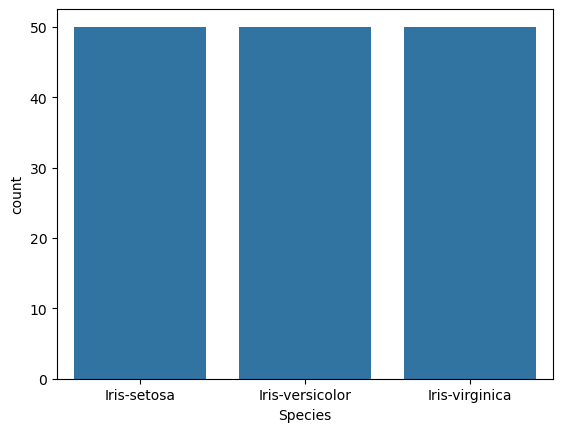

In [17]:
# Seaborn countplot ile her türün sayısını sütun grafiği olarak görselleştirir
sns.countplot(data=newDataset, x="Species")
plt.show()

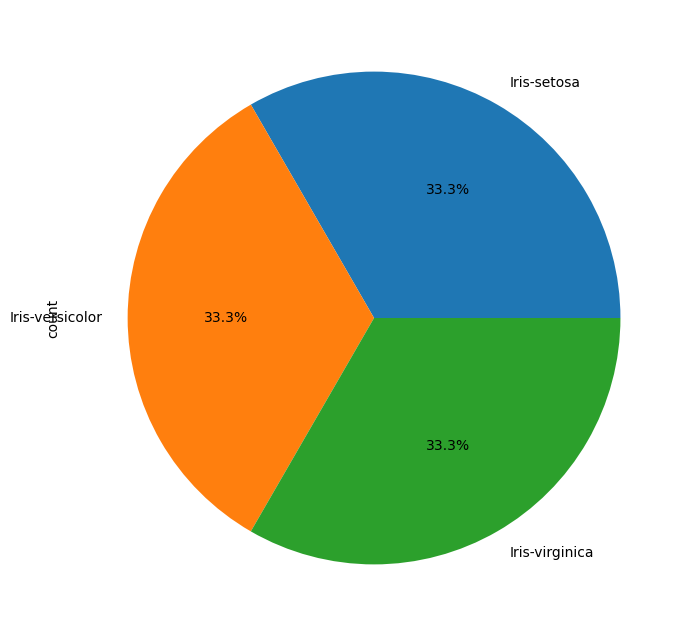

In [18]:
# Türlerin yüzdelik dağılımını pasta grafiği ile gösterir (autopct: yüzde değerlerini yazdırır)
data["Species"].value_counts().plot.pie(autopct='%1.1f%%',figsize=(10,8))
plt.show()

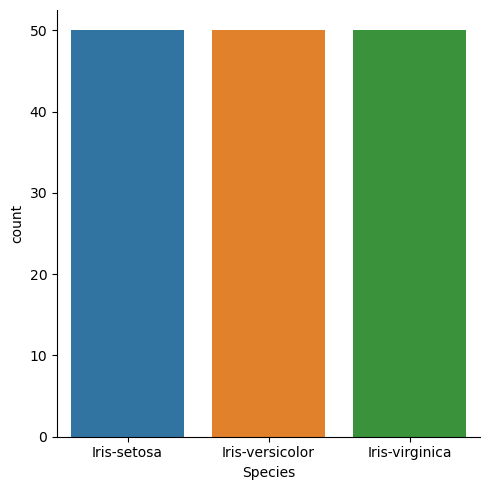

In [19]:
# Kategorik grafik (catplot) ile türlere göre sayım grafiği çizdirilir
sns.catplot(x="Species", hue="Species", kind='count', data=data)
plt.show()

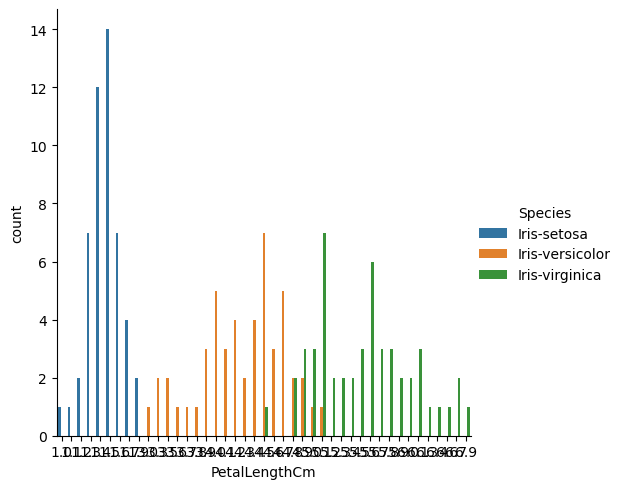

In [20]:
# PetalLengthCm değerlerinin türlere göre dağılımını kategorik grafikle gösterir
sns.catplot(x="PetalLengthCm", hue="Species", kind='count', data=data)
plt.show()

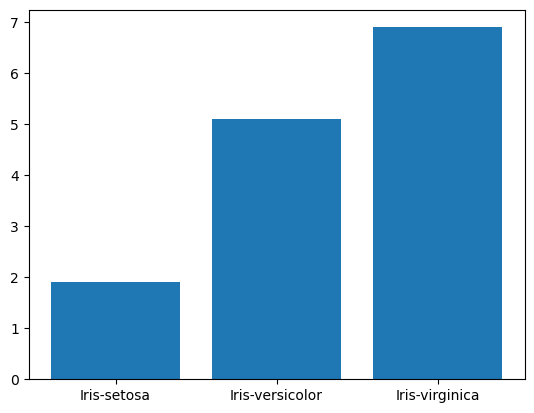

In [21]:
# Türlere göre PetalLengthCm değerlerini çubuk grafik (bar chart) ile gösterir
plt.bar(data['Species'],data['PetalLengthCm'])
plt.show()

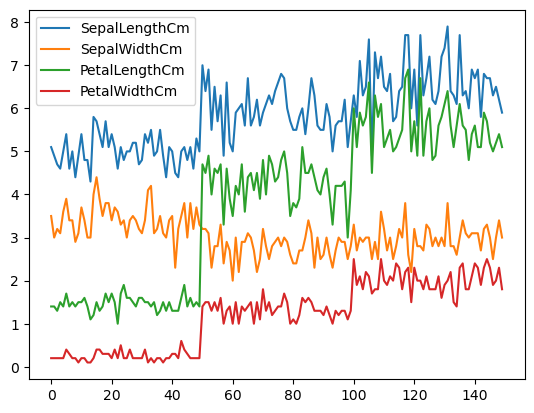

In [22]:
# Tüm sayısal sütunları tek bir çizgi grafiğinde gösterir
newDataset.plot()
plt.show()

In [23]:
# Her türün veri setinde kaç kez geçtiğini sayar
newDataset.Species.value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [24]:
# Veri setini tür bazında üç ayrı değişkene ayırır
setosa = data[data.Species=="Iris-setosa"]
versicolor = data[data.Species=="Iris-versicolor"]
virginica = data[data.Species=="Iris-virginica"]

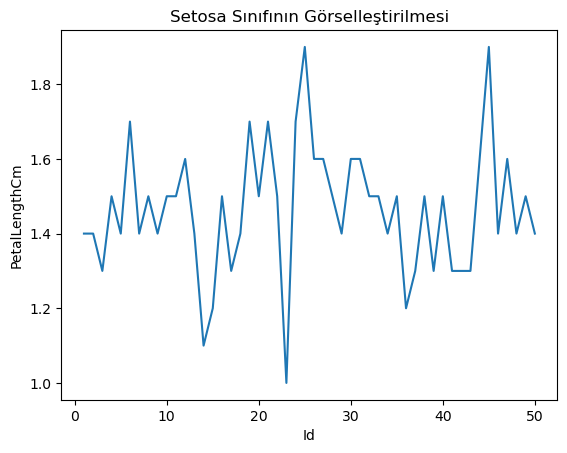

In [25]:
# Setosa türünün PetalLengthCm değerlerini çizgi grafiği ile görselleştirir
plt.plot(setosa.Id,setosa.PetalLengthCm)
plt.xlabel("Id")
plt.ylabel("PetalLengthCm")
plt.title("Setosa Sınıfının Görselleştirilmesi")
plt.show()

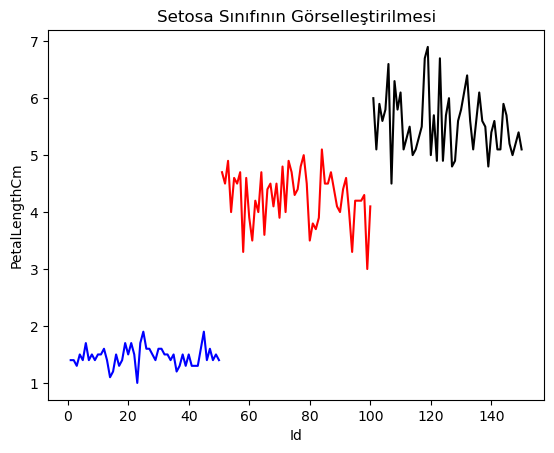

In [26]:
# Üç türün PetalLengthCm değerlerini aynı grafik üzerinde karşılaştırmalı olarak çizer
plt.plot(setosa.Id,setosa.PetalLengthCm,color="blue",label='setosa')
plt.plot(virginica.Id,virginica.PetalLengthCm,color="black",label='virginica')
plt.plot(versicolor.Id,versicolor.PetalLengthCm,color="red",label='versicolor')
plt.xlabel("Id")
plt.ylabel("PetalLengthCm")
plt.title("Setosa Sınıfının Görselleştirilmesi")
plt.show()

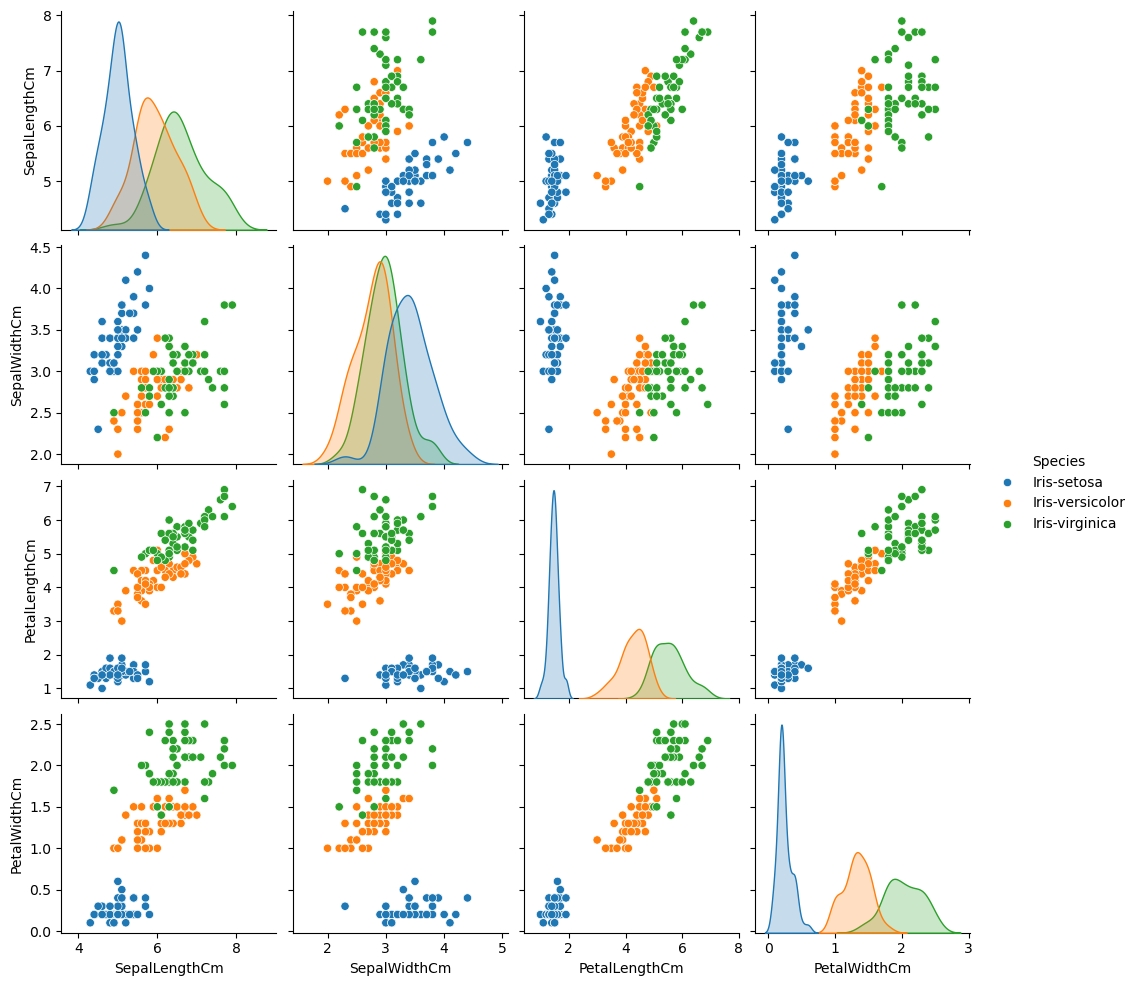

In [27]:
# Tüm özellik çiftlerinin birbirine göre dağılımını türlere göre renklendirilmiş şekilde çizer
sns.pairplot(newDataset, hue="Species")
plt.show()

In [28]:
# Veri setindeki sütun isimlerini listeler
data.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

<Axes: xlabel='SepalLengthCm', ylabel='PetalLengthCm'>

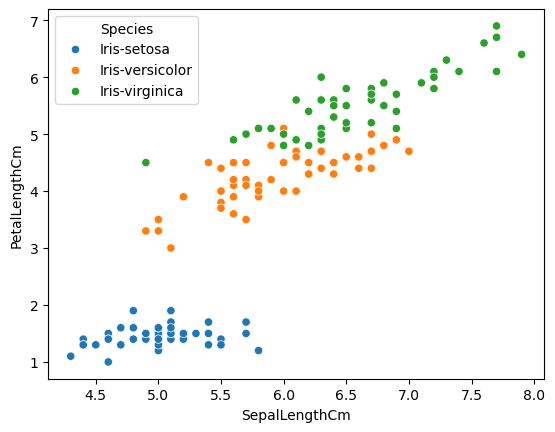

In [29]:
# SepalLengthCm ve PetalLengthCm arasındaki ilişkiyi türlere göre saçılım grafiği ile gösterir
sns.scatterplot(data=data, x="SepalLengthCm", y="PetalLengthCm", hue="Species")

<Axes: xlabel='SepalWidthCm', ylabel='PetalWidthCm'>

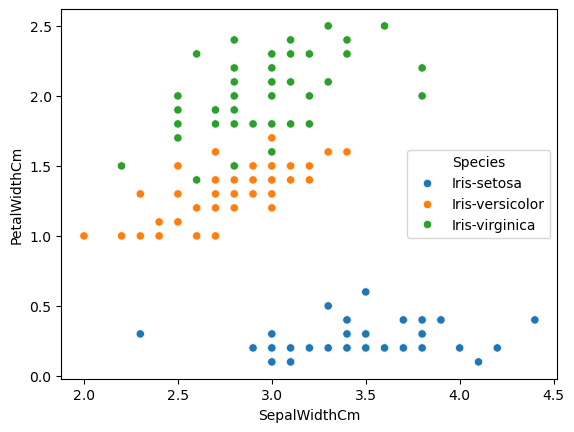

In [30]:
# SepalWidthCm ve PetalWidthCm arasındaki ilişkiyi türlere göre saçılım grafiği ile gösterir
sns.scatterplot(data=data, x="SepalWidthCm", y="PetalWidthCm", hue="Species")

In [ ]:
# Tüm sayısal sütunlar arasındaki korelasyon (ilişki) matrisini hesaplar
data.corr(numeric_only=True)

In [ ]:
# Id sütunu çıkarılmış veri setinde korelasyon matrisini hesaplar
newDataset.corr(numeric_only=True)

In [ ]:
# Korelasyon matrisini bir değişkene atar — ısı haritası (heatmap) çiziminde kullanılacak
correlation = newDataset.corr(numeric_only=True)

In [ ]:
# Korelasyon matrisini ısı haritası (heatmap) olarak görselleştirir — annot=True değerleri hücrelere yazar
sns.heatmap(correlation,annot = True)
plt.show()

In [ ]:
# PetalWidthCm ve PetalLengthCm arasındaki ilişkiyi türlere göre saçılım grafiği ile gösterir (en yüksek korelasyon: 0.96)
sns.scatterplot(data=data, x="PetalWidthCm", y="PetalLengthCm", hue="Species")

In [ ]:
# PetalLengthCm ve SepalWidthCm arasındaki ilişkiyi türlere göre saçılım grafiği ile gösterir (negatif korelasyon: -0.42)
sns.scatterplot(data=data, x="PetalLengthCm", y="SepalWidthCm", hue="Species")